In [3]:
import pandas as pd
from pathlib import Path
#import pyarrow.parquet as pq

train_path = Path(Path.cwd(), 'data', 'Zzzs_train.parquet')
train_path

WindowsPath('c:/Users/leami/Documents/3A/AML/Project_Sleep_States/data/Zzzs_train.parquet')

In [4]:
train_series = pd.read_parquet(train_path)
print(train_series.head())

      series_id  step                 timestamp     anglez    enmo  awake
0  08db4255286f     0  2018-11-05T10:00:00-0400 -30.845301  0.0447      1
1  08db4255286f     1  2018-11-05T10:00:05-0400 -34.181801  0.0443      1
2  08db4255286f     2  2018-11-05T10:00:10-0400 -33.877102  0.0483      1
3  08db4255286f     3  2018-11-05T10:00:15-0400 -34.282101  0.0680      1
4  08db4255286f     4  2018-11-05T10:00:20-0400 -34.385799  0.0768      1


In [5]:
train_series.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13165560 entries, 0 to 13165559
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   series_id  object 
 1   step       uint32 
 2   timestamp  object 
 3   anglez     float32
 4   enmo       float32
 5   awake      int64  
dtypes: float32(2), int64(1), object(2), uint32(1)
memory usage: 452.0+ MB


In [6]:
train_multi_path = Path(Path.cwd(), 'data', 'Zzzs_train_multi.parquet')
train_multi_series = pd.read_parquet(train_multi_path)
train_multi_series.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16289820 entries, 0 to 16289819
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   series_id  object 
 1   step       uint32 
 2   timestamp  object 
 3   anglez     float32
 4   enmo       float32
 5   awake      int64  
dtypes: float32(2), int64(1), object(2), uint32(1)
memory usage: 559.3+ MB


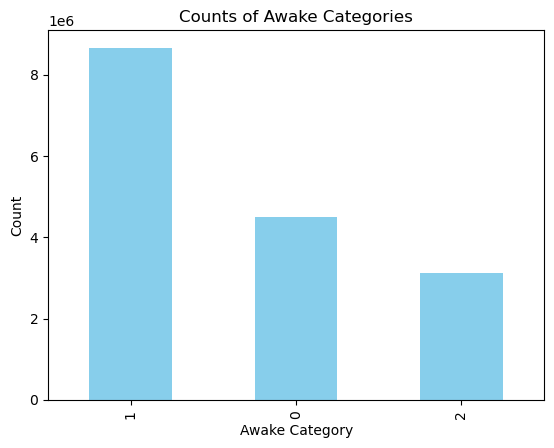

In [7]:
import matplotlib.pyplot as plt
awake_counts = train_multi_series['awake'].value_counts()
awake_counts.plot(kind='bar', color='skyblue')
plt.title('Counts of Awake Categories')
plt.xlabel('Awake Category')
plt.ylabel('Count')
plt.show()

In [8]:
import seaborn as sns

numeric_df = train_series.drop(columns=["series_id", "timestamp"])
corr_matrix = numeric_df.corr()

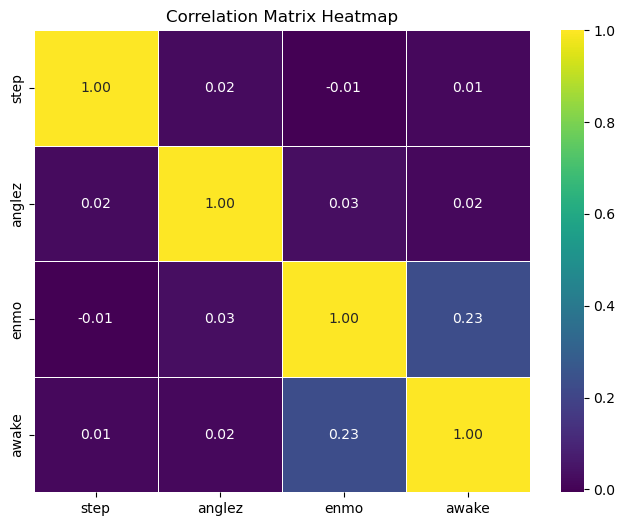

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="viridis", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [10]:
print('awake values:', train_series.awake.value_counts())
print('ID unique values:', train_series.series_id.nunique(), f'\n{train_series.series_id.unique()}')

awake values: awake
1    8660676
0    4504884
Name: count, dtype: int64
ID unique values: 35 
['08db4255286f' '0a96f4993bd7' '0cfc06c129cc' '1087d7b0ff2e'
 '10f8bc1f7b07' '18b61dd5aae8' '29c75c018220' '3452b878e596'
 '349c5562ee2c' '3664fe9233f9' '483d6545417f' '55a47ff9dc8a'
 '5acc9d63b5fd' '5f94bb3e1bed' '655f19eabf1e' '67f5fc60e494'
 '72bbd1ac3edf' '76237b9406d5' '7822ee8fe3ec' '89bd631d1769'
 '8e32047cbc1f' '939932f1822d' '9ee455e4770d' 'a9a2f7fac455'
 'a9e5f5314bcb' 'af91d9a50547' 'b364205aba43' 'c535634d7dcd'
 'c6788e579967' 'c68260cc9e8f' 'ca730dbf521d' 'd150801f3145'
 'd25e479ecbb7' 'd515236bdeec' 'd5e47b94477e']


In [11]:
uniques_ids = train_series.series_id.unique()
for idu in uniques_ids:
    # your_id = "0a96f4993bd7"  
    filtered_df = train_series[train_series["series_id"] == idu]
    print(f'ID {idu} data {filtered_df.shape}')

ID 08db4255286f data (440280, 6)
ID 0a96f4993bd7 data (256860, 6)
ID 0cfc06c129cc data (384660, 6)
ID 1087d7b0ff2e data (410940, 6)
ID 10f8bc1f7b07 data (392400, 6)
ID 18b61dd5aae8 data (495540, 6)
ID 29c75c018220 data (464220, 6)
ID 3452b878e596 data (535500, 6)
ID 349c5562ee2c data (37080, 6)
ID 3664fe9233f9 data (379980, 6)
ID 483d6545417f data (287460, 6)
ID 55a47ff9dc8a data (412740, 6)
ID 5acc9d63b5fd data (407880, 6)
ID 5f94bb3e1bed data (404280, 6)
ID 655f19eabf1e data (387360, 6)
ID 67f5fc60e494 data (376380, 6)
ID 72bbd1ac3edf data (390960, 6)
ID 76237b9406d5 data (412920, 6)
ID 7822ee8fe3ec data (408060, 6)
ID 89bd631d1769 data (429300, 6)
ID 8e32047cbc1f data (405540, 6)
ID 939932f1822d data (414540, 6)
ID 9ee455e4770d data (389880, 6)
ID a9a2f7fac455 data (634680, 6)
ID a9e5f5314bcb data (155160, 6)
ID af91d9a50547 data (411840, 6)
ID b364205aba43 data (401940, 6)
ID c535634d7dcd data (136080, 6)
ID c6788e579967 data (395640, 6)
ID c68260cc9e8f data (310860, 6)
ID ca730dbf

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_relationship(df, x_col, y_col, series_id=None, plot_type="scatter", color='b'):
    """
    Creates two subplots:
    - Top: 'awake' vs x_col (smaller)
    - Bottom: y_col vs x_col (larger)
    
    Parameters:
    - df (DataFrame): The dataset.
    - x_col (str): Column name for the x-axis.
    - y_col (str): Column name for the second y-axis.
    - series_id (str, optional): If provided, filters data for that series_id.
    - plot_type (str): "scatter" (default) or "line" for different visualizations.
    - color (str): Color for the primary variable (y_col).
    """
    # Filter by series_id if provided
    if series_id:
        df = df[df["series_id"] == series_id][:15000]
    
    # Create subplots with different heights (1 for top, 3 for bottom)
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [1, 3]})
    
    # Top plot: Awake vs. X (smaller)
    if plot_type == "scatter":
        sns.scatterplot(data=df, x=x_col, y="awake", alpha=0.5, color='deepskyblue', ax=axes[0])
    else:
        sns.lineplot(data=df, x=x_col, y="awake", color='deepskyblue', ax=axes[0])
    
    axes[0].set_title(f"Awake vs {x_col}")
    axes[0].set_ylabel("Awake")
    axes[0].grid(True)

    # Bottom plot: Y vs. X (larger)
    if plot_type == "scatter":
        sns.scatterplot(data=df, x=x_col, y=y_col, alpha=0.5, color=color, ax=axes[1])
    else:
        sns.lineplot(data=df, x=x_col, y=y_col, color=color, ax=axes[1])
    
    axes[1].set_title(f"{y_col} vs {x_col}")
    axes[1].set_xlabel(x_col)
    axes[1].set_ylabel(y_col)
    axes[1].grid(True)

    # Show plot
    plt.tight_layout()
    plt.show()


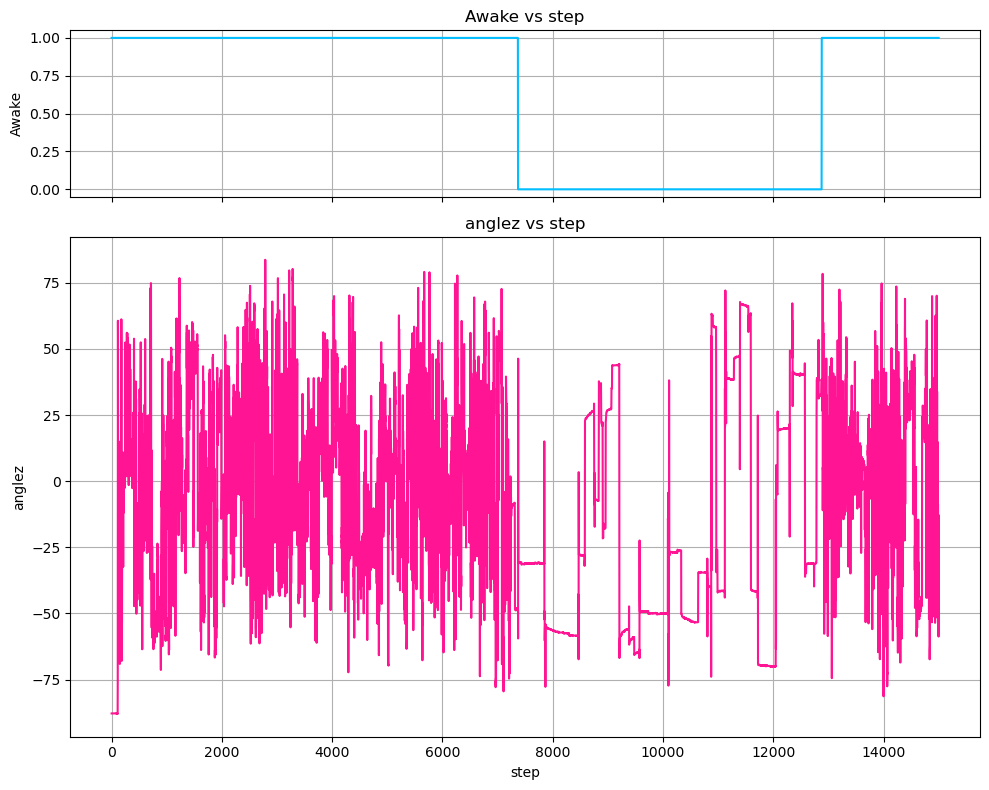

In [13]:
plot_relationship(train_multi_series, "step", "anglez", series_id="1087d7b0ff2e", plot_type="line", color='deeppink')

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_sleep_series(df, series_id):
    """Plots anglez, enmo, and awake over time for a given series_id."""
    df_series = df[df['series_id'] == series_id][:10000]

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    
    sns.lineplot(data=df_series, x="step", y="anglez", ax=axes[0], label="Angle Z", color="tomato")
    axes[0].set_title("Angle Z over Time")
    axes[0].grid('on')
    
    sns.lineplot(data=df_series, x="step", y="enmo", ax=axes[1], label="ENMO", color="darkslateblue")
    axes[1].set_title("ENMO over Time")
    axes[1].grid('on')
    
    sns.lineplot(data=df_series, x="step", y="awake", ax=axes[2], label="Awake", color="red")
    axes[2].set_title("Awake State over Time")
    axes[2].grid('on')
    
    plt.xlabel("Step")
    plt.tight_layout()
    plt.show()

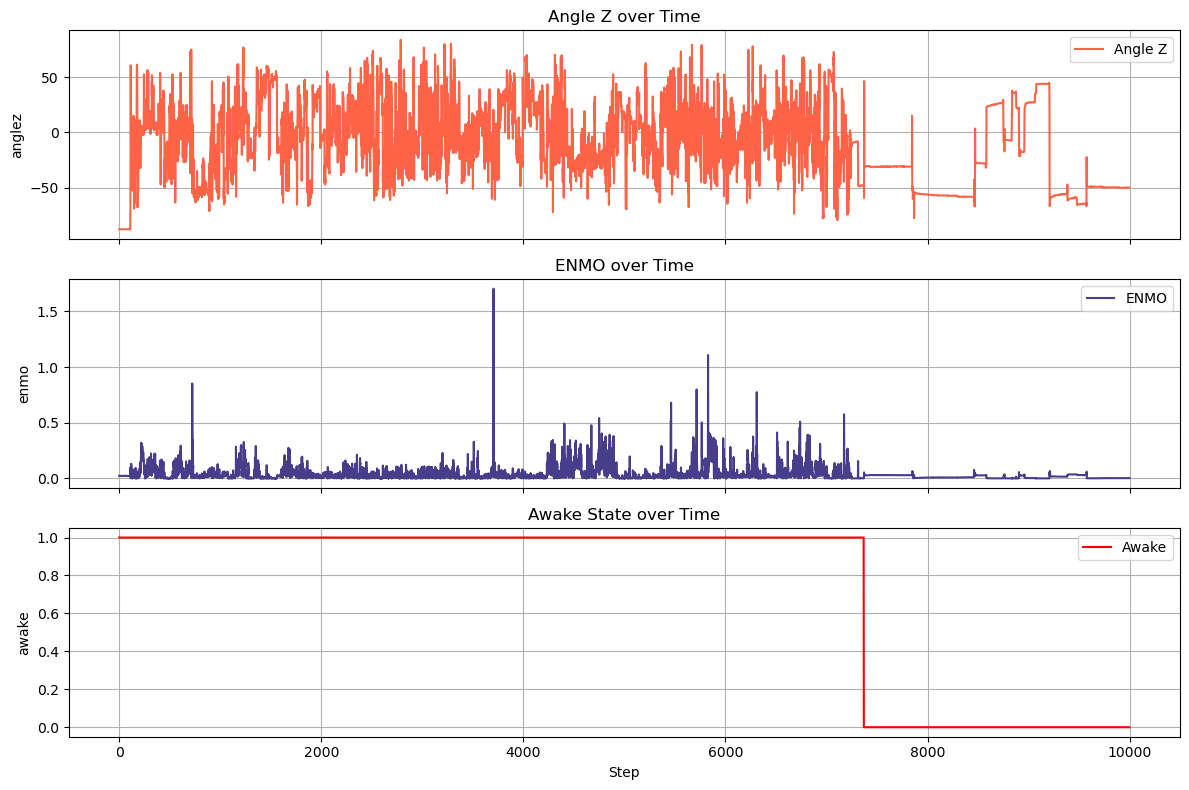

In [15]:
plot_sleep_series(train_series, "1087d7b0ff2e")

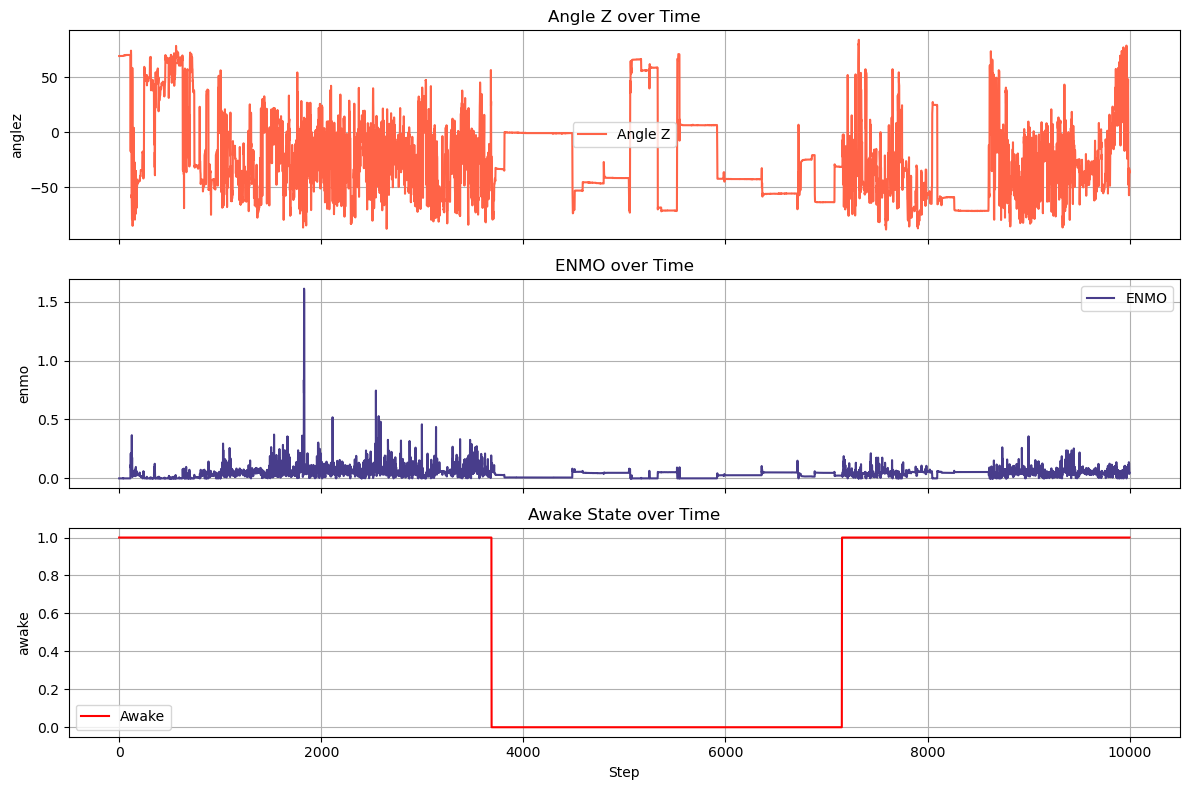

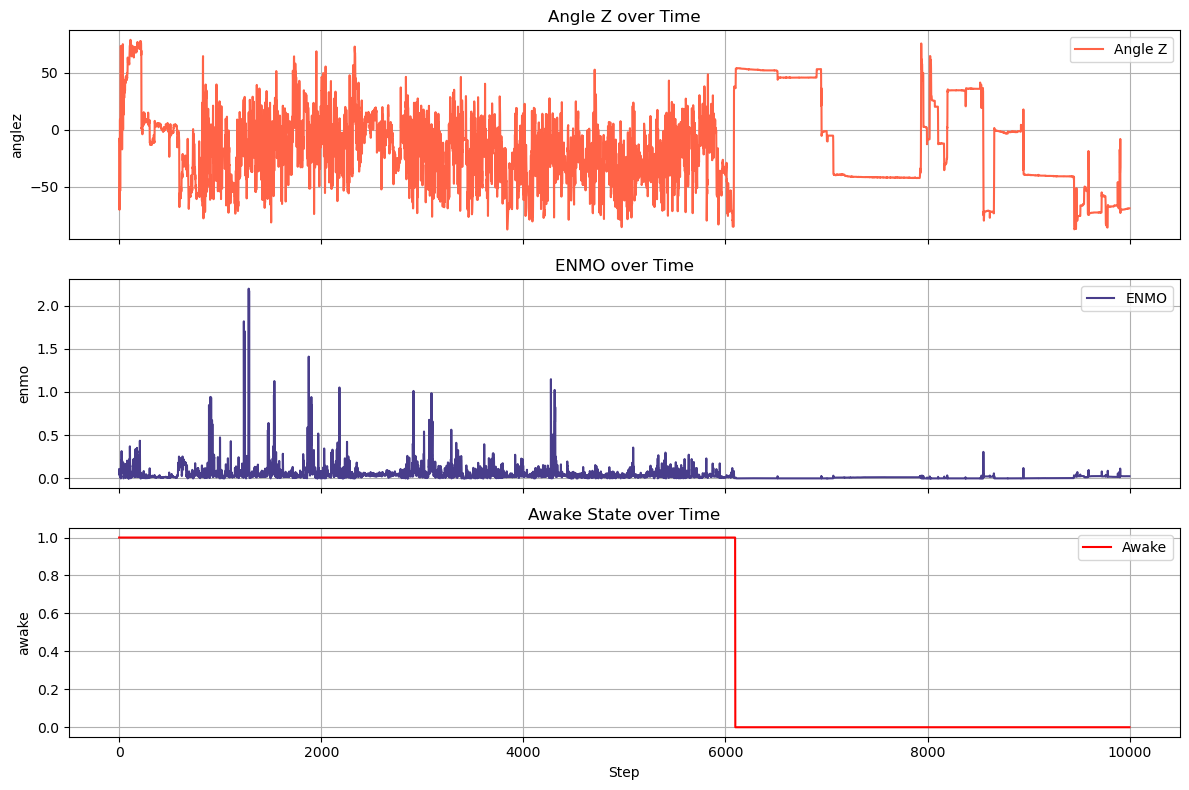

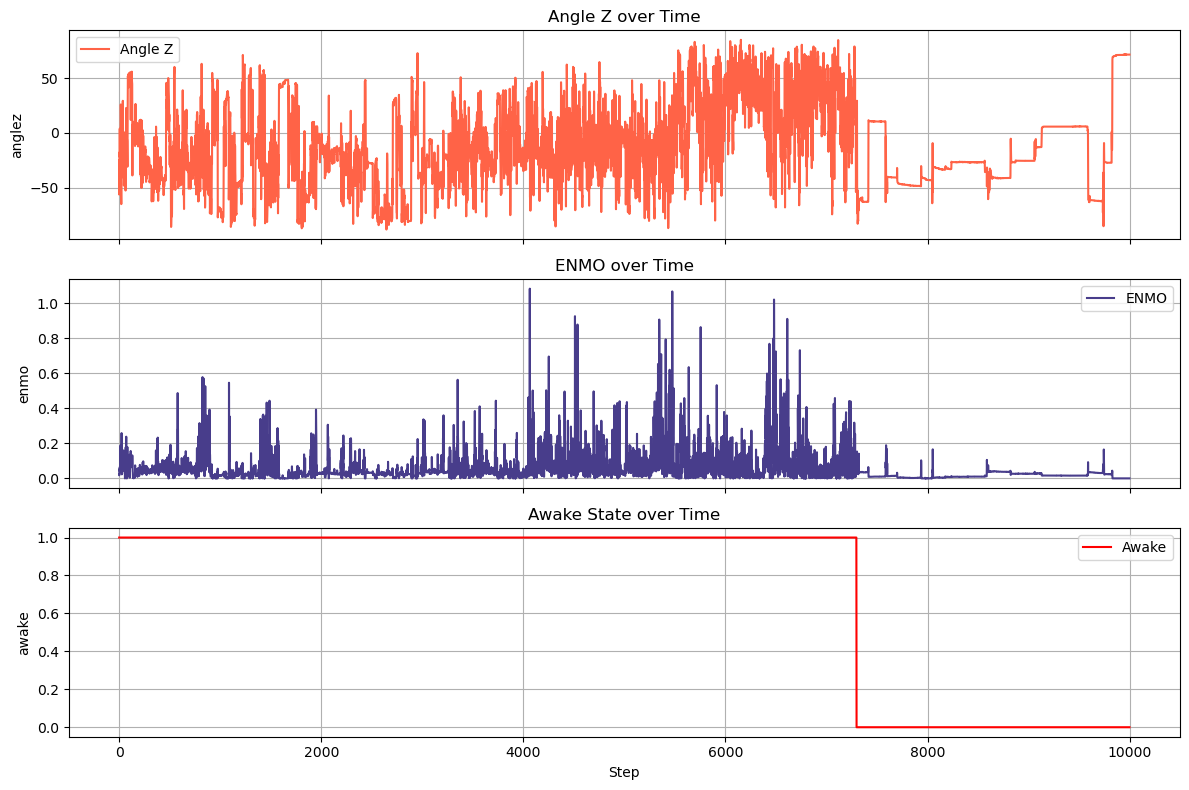

In [16]:
# '89bd631d1769' '8e32047cbc1f' '939932f1822d' '9ee455e4770d' 
plot_sleep_series(train_series, "89bd631d1769")
plot_sleep_series(train_series, "8e32047cbc1f")
plot_sleep_series(train_series, "939932f1822d")

In [17]:
def feature_engineering(df):
    """Adds rolling mean and standard deviation for anglez and enmo."""
    df["anglez_mean"] = df["anglez"].rolling(window=10, min_periods=1).mean()
    df["anglez_std"] = df["anglez"].rolling(window=10, min_periods=1).std()
    df["enmo_mean"] = df["enmo"].rolling(window=10, min_periods=1).mean()
    df["enmo_std"] = df["enmo"].rolling(window=10, min_periods=1).std()
    
    return df

df = feature_engineering(train_multi_series)

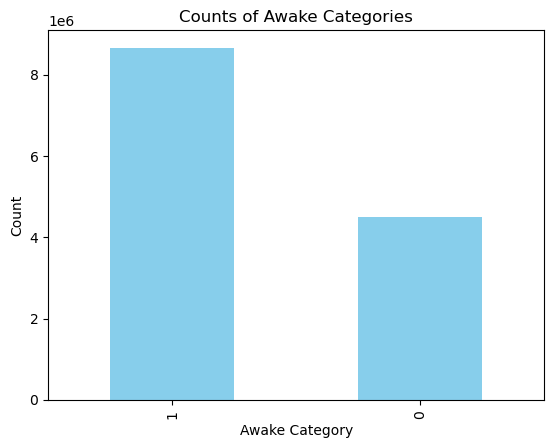

In [18]:
awake_counts = train_series['awake'].value_counts()
awake_counts.plot(kind='bar', color='skyblue')
plt.title('Counts of Awake Categories')
plt.xlabel('Awake Category')
plt.ylabel('Count')
plt.show()

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from tqdm import tqdm

# Función para extraer features estadísticas por ventanas con tqdm
def extract_features(df, sequence_length=50):
    features, labels = [], []
    series_ids = df['series_id'].unique()
    
    for series_id in tqdm(series_ids, desc="Procesando series"):
        sub_df = df[df['series_id'] == series_id]
        for i in range(0, len(sub_df) - sequence_length, sequence_length):
            window = sub_df.iloc[i:i+sequence_length]
            features.append([
                window['anglez'].mean(), window['anglez'].std(), window['anglez'].max(), window['anglez'].min(),
                window['enmo'].mean(), window['enmo'].std(), window['enmo'].max(), window['enmo'].min()
            ])
            labels.append(window.iloc[-1]['awake'])
    
    return np.array(features), np.array(labels)

In [20]:
train_series = train_series.drop(columns=['timestamp'])

In [21]:
X, y = extract_features(train_series, sequence_length=50)

Procesando series: 100%|██████████| 35/35 [01:39<00:00,  2.84s/it]


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
model = lgb.LGBMClassifier()
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 138504, number of negative: 72129
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001804 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 210633, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.657561 -> initscore=0.652443
[LightGBM] [Info] Start training from score 0.652443


LGBMClassifier()

Accuracy: 0.9140
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.88      0.87     17981
           1       0.94      0.93      0.93     34678

    accuracy                           0.91     52659
   macro avg       0.90      0.91      0.90     52659
weighted avg       0.91      0.91      0.91     52659



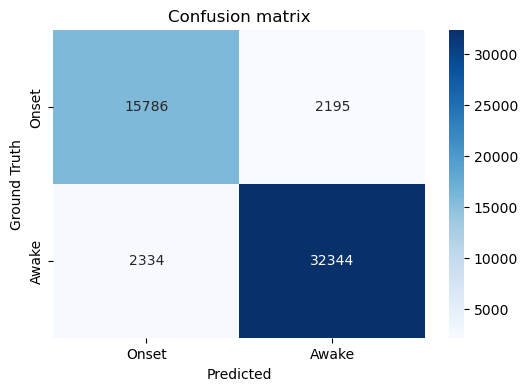

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones en el conjunto de test
y_pred = model.predict(X_test)

# 1. Precisión (accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# 2. Reporte de clasificación (Precision, Recall, F1)
print("Classification Report:\n", classification_report(y_test, y_pred))

# 3. Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)

# 4. Visualizar la matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Onset", "Awake"], yticklabels=["Onset", "Awake"])
plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.title("Confusion matrix")
plt.show()


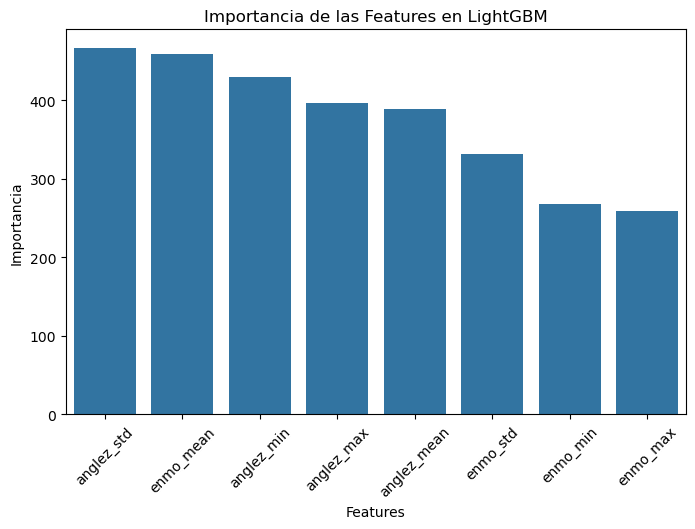

In [25]:
importances = model.feature_importances_
feature_names = ["anglez_mean", "anglez_std", "anglez_max", "anglez_min", 
                 "enmo_mean", "enmo_std", "enmo_max", "enmo_min"]

sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
sns.barplot(x=np.array(feature_names)[sorted_idx], y=importances[sorted_idx])
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importancia")
plt.title("Importancia de las Features en LightGBM")
plt.show()


In [26]:
train_multi_series = train_multi_series.drop(columns=['timestamp'])

In [27]:
X_multi, y_multi = extract_features(train_multi_series, sequence_length=50)

Procesando series: 100%|██████████| 43/43 [04:33<00:00,  6.36s/it]


In [28]:
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

In [29]:
model_multi = lgb.LGBMClassifier()
model_multi.fit(X_train_multi, y_train_multi)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004440 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 260618, number of used features: 8
[LightGBM] [Info] Start training from score -1.285113
[LightGBM] [Info] Start training from score -0.631658
[LightGBM] [Info] Start training from score -1.651973


LGBMClassifier()

Accuracy: 0.8295
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.84     18018
           1       0.85      0.90      0.87     34609
           2       0.80      0.60      0.68     12528

    accuracy                           0.83     65155
   macro avg       0.82      0.79      0.80     65155
weighted avg       0.83      0.83      0.83     65155



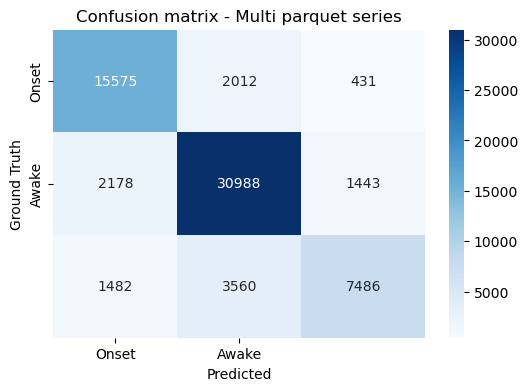

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones en el conjunto de test
y_pred_multi = model_multi.predict(X_test_multi)

# 1. Precisión (accuracy)
accuracy = accuracy_score(y_test_multi, y_pred_multi)
print(f"Accuracy: {accuracy:.4f}")

# 2. Reporte de clasificación (Precision, Recall, F1)
print("Classification Report:\n", classification_report(y_test_multi, y_pred_multi))

# 3. Matriz de confusión
conf_matrix = confusion_matrix(y_test_multi, y_pred_multi)

# 4. Visualizar la matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Onset", "Awake"], yticklabels=["Onset", "Awake"])
plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.title("Confusion matrix - Multi parquet series")
plt.show()

In [31]:
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb
import numpy as np

# Definir el modelo
model_multi = lgb.LGBMClassifier()

# Definir el espacio de hiperparámetros a buscar
param_dist = {
    'num_leaves': np.arange(20, 200, 10),        # Número de hojas en los árboles
    'learning_rate': np.logspace(-3, 0, 10),     # Tasa de aprendizaje (0.001 a 1)
    'n_estimators': np.arange(50, 500, 50),      # Número de árboles
    'max_depth': np.arange(3, 15, 2),            # Profundidad máxima del árbol
    'min_child_samples': np.arange(10, 100, 10), # Mínimo de muestras por hoja
    'subsample': np.linspace(0.5, 1.0, 5),       # Proporción de muestras para cada árbol
    'colsample_bytree': np.linspace(0.5, 1.0, 5) # Proporción de características por árbol
}

# Definir RandomizedSearchCV
random_search = RandomizedSearchCV(
    model_multi, param_distributions=param_dist,
    n_iter=50,  # Número de combinaciones a probar
    scoring='accuracy',  # Métrica de evaluación
    cv=3,  # Validación cruzada
    verbose=2,
    n_jobs=-1,  # Usa todos los núcleos disponibles
    random_state=42
)

# Ejecutar la búsqueda
random_search.fit(X_train, y_train)

# Mostrar los mejores parámetros encontrados
print("Mejores parámetros:", random_search.best_params_)
print("Mejor puntuación de validación:", random_search.best_score_)


Fitting 3 folds for each of 50 candidates, totalling 150 fits
[LightGBM] [Info] Number of positive: 138504, number of negative: 72129
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001288 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 210633, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.657561 -> initscore=0.652443
[LightGBM] [Info] Start training from score 0.652443
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

In [32]:
model_multi = lgb.LGBMClassifier(
    subsample=0.5,
    num_leaves=110,
    n_estimators=350,
    min_child_samples=90,
    max_depth=13,
    learning_rate=0.1,
    colsample_bytree=1.0
)

model_multi.fit(X_train_multi, y_train_multi)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004203 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 260618, number of used features: 8
[LightGBM] [Info] Start training from score -1.285113
[LightGBM] [Info] Start training from score -0.631658
[LightGBM] [Info] Start training from score -1.651973
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

LGBMClassifier(max_depth=13, min_child_samples=90, n_estimators=350,
               num_leaves=110, subsample=0.5)

Accuracy: 0.8719
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.88      0.86     18018
           1       0.88      0.91      0.90     34609
           2       0.88      0.74      0.80     12528

    accuracy                           0.87     65155
   macro avg       0.87      0.85      0.86     65155
weighted avg       0.87      0.87      0.87     65155



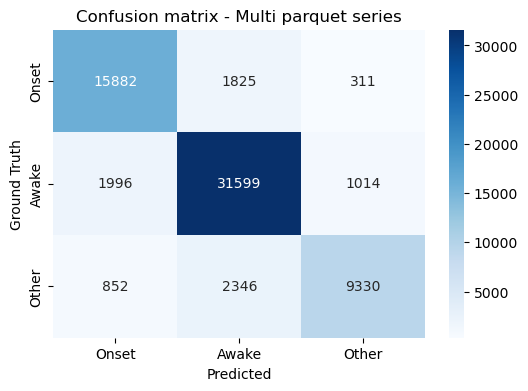

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones en el conjunto de test
y_pred_multi = model_multi.predict(X_test_multi)

# 1. Precisión (accuracy)
accuracy = accuracy_score(y_test_multi, y_pred_multi)
print(f"Accuracy: {accuracy:.4f}")

# 2. Reporte de clasificación (Precision, Recall, F1)
print("Classification Report:\n", classification_report(y_test_multi, y_pred_multi))

# 3. Matriz de confusión
conf_matrix = confusion_matrix(y_test_multi, y_pred_multi)

# 4. Visualizar la matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Onset", "Awake", "Other"], yticklabels=["Onset", "Awake", "Other"])
plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.title("Confusion matrix - Multi parquet series")
plt.show()

In [34]:
import pandas as pd
import polars as pl

test = (pl.scan_parquet("./Data/test_series.parquet")
          .with_columns(
              (pl.col("timestamp")
                 .str.strptime(pl.Datetime, "%Y-%m-%dT%H:%M:%S%Z")
                 .dt.hour()
                 .alias("hour")
              )
          )
          .drop("timestamp")
          .collect()
          .to_pandas()
)


print(test['series_id'].nunique())
print(test.head())

3
      series_id  step  anglez    enmo  hour
0  038441c925bb     0  2.6367  0.0217    15
1  038441c925bb     1  2.6368  0.0215    15
2  038441c925bb     2  2.6370  0.0216    15
3  038441c925bb     3  2.6368  0.0213    15
4  038441c925bb     4  2.6368  0.0215    15


In [35]:
# Numero de lineas en el dataset
print(test.shape)

(450, 5)


In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from tqdm import tqdm

def extract_features_test(df, sequence_length=50):
    features = []
    windows_metadata = []  # Pour stocker les métadonnées de chaque fenêtre
    series_ids = df['series_id'].unique()
   
    for series_id in tqdm(series_ids, desc="Procesando series"):
        sub_df = df[df['series_id'] == series_id]
        # Si le dataframe n'est pas vide
        if not sub_df.empty:
            # Assurer que nous avons assez de données pour au moins une fenêtre
            if len(sub_df) >= sequence_length:
                for i in range(0, len(sub_df) - sequence_length + 1, sequence_length):
                    window = sub_df.iloc[i:i+sequence_length]
                    
                    # Extraire les features
                    features.append([
                        window['anglez'].mean(), window['anglez'].std(), window['anglez'].max(), window['anglez'].min(),
                        window['enmo'].mean(), window['enmo'].std(), window['enmo'].max(), window['enmo'].min()
                    ])
                    
                    # Stocker les métadonnées pour cette fenêtre
                    windows_metadata.append({
                        'series_id': series_id,
                        'start_step': window['step'].iloc[0],
                        'end_step': window['step'].iloc[-1],
                        'start_idx': i,
                        'end_idx': i + sequence_length - 1,
                        'step': window['step'].iloc[0]  # Utiliser le premier step comme identifiant
                    })
            else:
                # Pour les séries trop courtes, utiliser toutes les données disponibles
                window = sub_df
                features.append([
                    window['anglez'].mean(), window['anglez'].std(), window['anglez'].max(), window['anglez'].min(),
                    window['enmo'].mean(), window['enmo'].std(), window['enmo'].max(), window['enmo'].min()
                ])
                
                # Stocker les métadonnées
                windows_metadata.append({
                    'series_id': series_id,
                    'start_step': window['step'].iloc[0],
                    'end_step': window['step'].iloc[-1],
                    'start_idx': 0,
                    'end_idx': len(window) - 1,
                    'step': window['step'].iloc[0]  # Utiliser le premier step comme identifiant
                })
   
    # Vérification que features n'est pas vide
    if not features:
        raise ValueError("Aucune feature n'a été extraite, vérifiez vos données d'entrée.")
    
    # Créer un DataFrame condensé avec une ligne par fenêtre
    condensed_df = pd.DataFrame(windows_metadata)
    
    # Convertir les features en array NumPy
    X_test = np.array(features)
        
    return X_test, condensed_df

# Exemple d'utilisation
# df_test = feature_engineering(test)
# X_test, df_test_selected = extract_features_test(df_test, sequence_length=30)
# y_pred = model_multi.predict(X_test)
# y_pred_proba = model_multi.predict_proba(X_test)

In [37]:
df_test = feature_engineering(test)
df_test.drop(columns=['hour'])
X_test, df_test_selected = extract_features_test(df_test, sequence_length=50)
y_pred = model_multi.predict(X_test)

print(f"Number of series in df_test_selected: {df_test_selected['series_id'].nunique()}")  # Imprimer le nombre de séries dans 

Procesando series: 100%|██████████| 3/3 [00:00<00:00, 203.62it/s]

Number of series in df_test_selected: 3


In [38]:
# Obtenir les prédictions brutes
test = df_test_selected.copy()
y_pred_proba = model_multi.predict_proba(X_test)
test['sleep_prob'] = y_pred_proba[:, 0]  # Probabilité de classe 0 (sommeil)
test['awake_prob'] = y_pred_proba[:, 1]  # Probabilité de classe 1 (éveil)

print(f"Nombre de séries dans test: {test['series_id'].nunique()}")
print(f"Nombre de lignes dans test: {len(test)}")

# Libérer la mémoire
del y_pred_proba

# Initialiser la liste pour stocker les événements
events = []

# Paramètres pour ajuster la détection (pas besoin de SLEEP_THRESHOLD ici)
# On va calculer la moyenne de sleep_prob pour chaque série
for series_id, group in test.groupby('series_id'):
    group = group.sort_values('step')
    print(f"Nombre de lignes pour {series_id} avant filtrage : {group.shape[0]}")

    # Calculer la moyenne de sleep_prob pour la série
    mean_sleep_prob = group['sleep_prob'].mean()
    print(f"Moyenne de sleep_prob pour la série {series_id}: {mean_sleep_prob}")
    
    # Déterminer les états (sommeil/éveil) en fonction de la moyenne de sleep_prob
    is_sleep = group['sleep_prob'] > mean_sleep_prob  # Utilisation de la moyenne comme seuil
    
    if is_sleep.any():  # Vérifie si au moins un événement de sommeil est trouvé
        print(f"Il y a des périodes de sommeil pour {series_id} avec la moyenne comme seuil")

    # Pour chaque ligne qui correspond à un début de sommeil
    for idx, row in group[is_sleep].iterrows():
        # Vérifier si cette ligne représente un début de période de sommeil
        # On peut utiliser start_step et end_step qui sont déjà dans notre DataFrame condensé
        
        # Ajouter l'événement onset
        events.append({
            'series_id': series_id,
            'step': row['start_step'],
            'event': 'onset',
            'score': row['sleep_prob']
        })
        
        # Ajouter l'événement wakeup
        events.append({
            'series_id': series_id,
            'step': row['end_step'],
            'event': 'wakeup',
            'score': 1 - row['sleep_prob']
        })

# Créer le DataFrame de soumission
submission = pd.DataFrame(events)

# Afficher les statistiques
print(f"Total events detected: {len(submission)}")
print(f"Onset events: {(submission['event'] == 'onset').sum()}")
print(f"Wakeup events: {(submission['event'] == 'wakeup').sum()}")
print(f"Unique series: {submission['series_id'].nunique()}")
print(f"Average events per series: {len(submission)/submission['series_id'].nunique():.1f}")

# Finaliser le format de soumission
submission = submission.reset_index(drop=True).reset_index(names="row_id")

# Sauvegarder la soumission
submission.to_csv('submission_lgbm_simplified.csv', index=False)

# Afficher un échantillon du fichier de soumission
print("\nSample of submission file:")
print(submission.head(20))


Nombre de séries dans test: 3
Nombre de lignes dans test: 9
Nombre de lignes pour 038441c925bb avant filtrage : 3
Moyenne de sleep_prob pour la série 038441c925bb: 0.7489722257325607
Il y a des périodes de sommeil pour 038441c925bb avec la moyenne comme seuil
Nombre de lignes pour 03d92c9f6f8a avant filtrage : 3
Moyenne de sleep_prob pour la série 03d92c9f6f8a: 0.11268781104520069
Il y a des périodes de sommeil pour 03d92c9f6f8a avec la moyenne comme seuil
Nombre de lignes pour 0402a003dae9 avant filtrage : 3
Moyenne de sleep_prob pour la série 0402a003dae9: 0.0008824565555447887
Il y a des périodes de sommeil pour 0402a003dae9 avec la moyenne comme seuil
Total events detected: 10
Onset events: 5
Wakeup events: 5
Unique series: 3
Average events per series: 3.3

Sample of submission file:
   row_id     series_id  step   event     score
0       0  038441c925bb    50   onset  0.787043
1       1  038441c925bb    99  wakeup  0.212957
2       2  038441c925bb   100   onset  0.872930
3       3